## Data Preprocessing

In [3]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv('customer_praktikum.csv')
print(f"{df.head(5)}")

   customer_id   age  monthly_income  account_balance      city  \
0            1  80.0       5342000.0       18784900.0   Bandung   
1            2  82.0       5880000.0       10389200.0  Surabaya   
2            3  79.0       8495000.0       19348000.0  Surabaya   
3            4  85.0       8221000.0       21778200.0   Jakarta   
4            5  90.0       6958000.0       17067200.0   Bandung   

  education_level has_credit_card  last_login_days  churn  
0              S2             Yes              NaN      1  
1             SMA             Yes              NaN      0  
2              S2              No              NaN      1  
3              D3             Yes              NaN      0  
4              S1             Yes              NaN      0  


### Handle missing value

In [7]:
mdf = df.isna().sum()
print(f"{mdf}")
print(df.info())

customer_id          0
age                 15
monthly_income      15
account_balance     15
city                15
education_level     15
has_credit_card     15
last_login_days    200
churn                0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      300 non-null    int64  
 1   age              285 non-null    float64
 2   monthly_income   285 non-null    float64
 3   account_balance  285 non-null    float64
 4   city             285 non-null    str    
 5   education_level  285 non-null    str    
 6   has_credit_card  285 non-null    str    
 7   last_login_days  100 non-null    float64
 8   churn            300 non-null    int64  
dtypes: float64(4), int64(2), str(3)
memory usage: 21.2 KB
None


In [10]:
# Memisahkan kolom numerik dan kategori
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['str']).columns

print(num_cols)
print(cat_cols)

Index(['customer_id', 'age', 'monthly_income', 'account_balance',
       'last_login_days', 'churn'],
      dtype='str')
Index(['city', 'education_level', 'has_credit_card'], dtype='str')


In [22]:
# Mengisi missing value di kolom numerik dengan rata-rata
for col in num_cols: 
    nilai_rata = df[col].median()
    df[col] = df[col].fillna(nilai_rata)
    print(f'Nilai rata-rata {col}: {nilai_rata}')

Nilai rata-rata customer_id: 150.5
Nilai rata-rata age: 35.73263157894736
Nilai rata-rata monthly_income: 7096000.0
Nilai rata-rata account_balance: 15439183.50877193
Nilai rata-rata last_login_days: 32.39
Nilai rata-rata churn: 1.0


In [23]:
for col in cat_cols:
    modus = df[col].mode()[0]
    df[col] = df[col].fillna(modus)
    print(f'Nilai modus {col}: {modus}')

Nilai modus city: Bandung
Nilai modus education_level: S1
Nilai modus has_credit_card: Yes


In [24]:
# Cek ulang nilai missing
df.isna().sum()

customer_id        0
age                0
monthly_income     0
account_balance    0
city               0
education_level    0
has_credit_card    0
last_login_days    0
churn              0
dtype: int64

In [27]:
# Menyimpan data yang sudah dihandle missing
df.to_csv('customer_praktikum_handled.csv', index=False)

## Outlier Detection & Treatment

In [32]:
df = pd.read_csv('customer_praktikum_handled.csv')
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

### Metode IQR

In [30]:
def iqr_bounds(series):  # Series -> Representasi satu kolom dalam bentuk array
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    higher_bound = q3 + 1.5 * iqr
    return lower_bound, higher_bound

In [35]:
# Menghitung batas outlier setiap column
for col in num_cols:
    lb, ub = iqr_bounds(df[col].dropna())
    print(f'Kolom {col}: {lb} - {ub}')

Kolom Unnamed: 0: -149.5 - 448.5
Kolom customer_id: -148.5 - 449.5
Kolom age: 9.225000000000009 - 60.624999999999986
Kolom monthly_income: 1851500.0 - 12089500.0
Kolom account_balance: 2893625.0 - 27747625.0
Kolom last_login_days: 32.39 - 32.39
Kolom churn: -1.5 - 2.5


In [36]:
# Membuat DataFrame baru penanda Outlier
outlier_iqr = pd.DataFrame(index=df.index)

# true -> Outlier, false -> No
for col in num_cols:
    lb, ub = iqr_bounds(df[col].dropna())
    outlier_iqr[col] = (df[col] < lb) | (df[col] > ub)

# Tampilkan seluruh outlier
print(outlier_iqr.sum())

Unnamed: 0           0
customer_id          0
age                  9
monthly_income       4
account_balance      5
last_login_days    100
churn                0
dtype: int64


In [37]:
# Treatment Outlier
df_treated = df.copy()    # Buat salinan data asli, agar yang ori tetap aman
print(df[num_cols].describe())

       Unnamed: 0  customer_id         age  monthly_income  account_balance  \
count  300.000000   300.000000  300.000000    3.000000e+02     3.000000e+02   
mean   149.500000   150.500000   35.732632    7.581621e+06     1.543918e+07   
std     86.746758    86.746758   11.484602    6.208602e+06     4.894889e+06   
min      0.000000     1.000000    2.600000    2.057000e+06     1.515600e+06   
25%     74.750000    75.750000   28.500000    5.690750e+06     1.221388e+07   
50%    149.500000   150.500000   35.732632    7.096000e+06     1.543918e+07   
75%    224.250000   225.250000   41.350000    8.250250e+06     1.842738e+07   
max    299.000000   300.000000   90.000000    8.000000e+07     2.816190e+07   

       last_login_days       churn  
count       300.000000  300.000000  
mean         32.390000    0.560000  
std          16.779023    0.497216  
min           0.400000    0.000000  
25%          32.390000    0.000000  
50%          32.390000    1.000000  
75%          32.390000    1.0

In [40]:
for col in num_cols:
    lb,ub = iqr_bounds(df_treated[col].dropna())
    df_treated[col] = np.where(df_treated[col] < lb, lb, df_treated[col])
    df_treated[col] = np.where(df_treated[col] < ub, ub, df_treated[col])


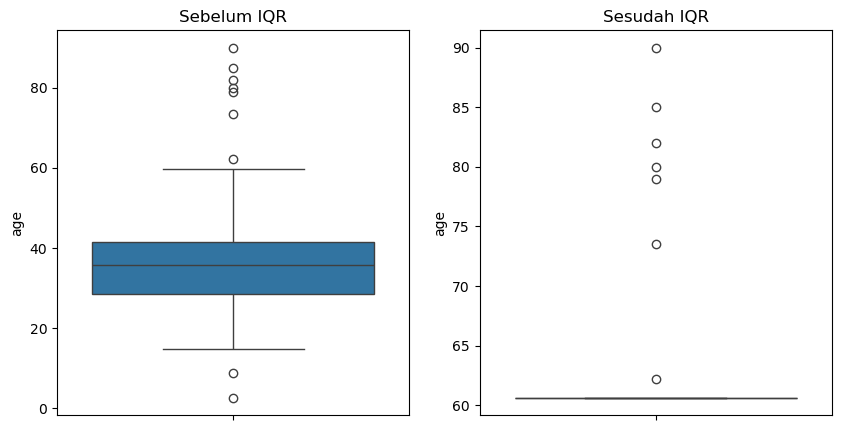

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

col = "age"

plt.figure(figsize=(10,5))

# Sebelum outlier dihitung
plt.subplot(1,2,1)
sns.boxplot(y=df[col])
plt.title("Sebelum IQR")

# Sesudah dihitung
plt.subplot(1,2,2)
sns.boxplot(y=df_treated[col])
plt.title("Sesudah IQR")

plt.show()